# Olympic-Year — do stocks win gold when the Games are on?
### Summer Olympics 1928–2024, 23 games, and a signal that does not show up

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth--check: BUSTED](https://img.shields.io/badge/Myth--check-BUSTED-8b949e?style=flat-square)

Every four years the Olympic Games roll around and so do the financial-media pieces asking: *is there an Olympic stock market effect?*  The claim is that global optimism, economic stimulus, or some unnamed seasonal rhythm makes markets do better in Olympic years.  Let us look at every Summer Olympics since 1928 and ask whether the pattern holds.

> This is the plain-language layer. The t-stats, permutation anatomy, and positive control live in the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from olympic_year import data, strategy as st

GSPC_CACHE = os.path.abspath(os.path.join("..", "_cache", "gspc_annual.parquet"))
HAVE_REAL = os.path.exists(GSPC_CACHE)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-16).
R = dict(
    n=97, year_min=1928, year_max=2024,
    n_olympic=23, n_non_olympic=74,
    mean_olympic=8.89, std_olympic=15.96,
    mean_non=7.74, std_non=19.99,
    grand_mean=8.01,
    contrast=1.15,
    hac_t=0.29, se=3.00,
    pval_two=0.803, pval_one=0.407,
    pre_n_oly=9, pre_mean_oly=9.16, pre_mean_non=5.63, pre_contrast=3.53,
    post_n_oly=14, post_mean_oly=8.71, post_mean_non=9.64, post_contrast=-0.92,
    strat_ann=1.75, bah_ann=6.17, advantage=-4.42,
    fp="b725f3543071",
    olympic_years=[
        1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972,
        1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012,
        2016, 2020, 2024,
    ],
    olympic_returns=[
        35.3, -10.8, 33.5, -0.7, 11.8, 2.6, -3.0, 13.0, 7.7, 15.6,
        19.1, 25.8, 1.4, 12.4, 4.5, 20.3, -10.1, 9.0, -38.5, 13.4,
        9.5, 16.3, 23.3,
    ],
)

if HAVE_REAL:
    df_real = data.load_gspc(cache_path=GSPC_CACHE)
    print(f"^GSPC tape loaded: {df_real.index.min()}-{df_real.index.max()}, "
          f"n={len(df_real)}, fp={data.fingerprint(df_real)}")
else:
    print("^GSPC cache not found -- falling back to frozen R numbers for charts.")


^GSPC tape loaded: 1928-2024, n=97, fp=b725f3543071


## The answer first

| Question | Answer |
|---|---|
| Do Olympic years outperform? | **Marginally and not significantly.** Mean +8.9% vs +7.7% non-Olympic — a gap of **+1.15 pp** in 97 years. |
| Is that statistically meaningful? | **No.** HAC *t* = +0.29; permutation p = 0.80. Well inside noise. |
| Is there a mechanism? | **None.** The IOC schedule has no causal link to corporate earnings or monetary policy. |
| Can you trade it? | **No.** An Olympic-only strategy yields +1.75%/yr vs +6.17%/yr buy-and-hold (you are in cash 76% of the time). |

> The raw mean difference is positive (+1.15 pp) but has a t-stat of +0.29 — a coin flip of a result.  The permutation p of 0.80 means 80% of random relabellings produce a gap at least this large.  This is as close to pure noise as a financial folklore claim can get.

## 1 . The claim

> *"The Summer Olympics tend to be a positive sign for stocks. The combination of global goodwill, international investment in host infrastructure, and consumer confidence during a year of global celebration pushes equities higher. Historically, most Olympic years have been positive for the market."*

-- Paraphrase of financial-media commentary circulating before the 2012, 2016, and 2020/2021 Games (CNBC, MarketWatch, Barron's).

The intuition, such as it is: the Olympic Games generate infrastructure spending, tourism, and international media coverage that boosts economic activity and investor sentiment.  The claim is rarely made with specific numbers or a statistical test — it is a vibe.

## 2 . So what?

If true, it would be a once-per-four-years calendar rule with no fundamental analysis required — just check whether it is an Olympic year and buy equities accordingly.  The stakes are modest (one year per four), but the concept is clean enough to test.

If false, it joins a long list of financial calendar effects that look plausible in financial-media prose and dissolve under basic statistical scrutiny.  The interesting failure mode here is not data-mining (there is only one Olympic calendar, not ten), but simply **brutal sample size**: 23 Summer Olympics in 97 years gives you one observation per 4.2 years, not enough to distinguish any real effect from the enormous year-to-year variance of equity returns (~19% annual vol).

## 3 . How would we even know?

Two tests:

1. **Show every Olympic year.** Not a cherry-picked subset — all 23. A real signal should produce consistently above-average returns, not a mix of +35% and −38% observations.
2. **Run the permutation test.** If we randomly relabelled 23 of the 97 years as 'Olympic' and measured the mean contrast, how often would we get a gap at least as large as the one we observe?  That frequency is the honest p-value.

Data: yfinance ^GSPC, December-close prices, 1928–2024, n = 97 calendar-year returns.  Olympic years: IOC official schedule (n = 23 games since 1928; WWII cancelled 1916/1940/1944).

## 4 . The teardown — every Olympic year, no cherry-picking

Here are all 23 Summer Olympic years in the sample, ranked chronologically.

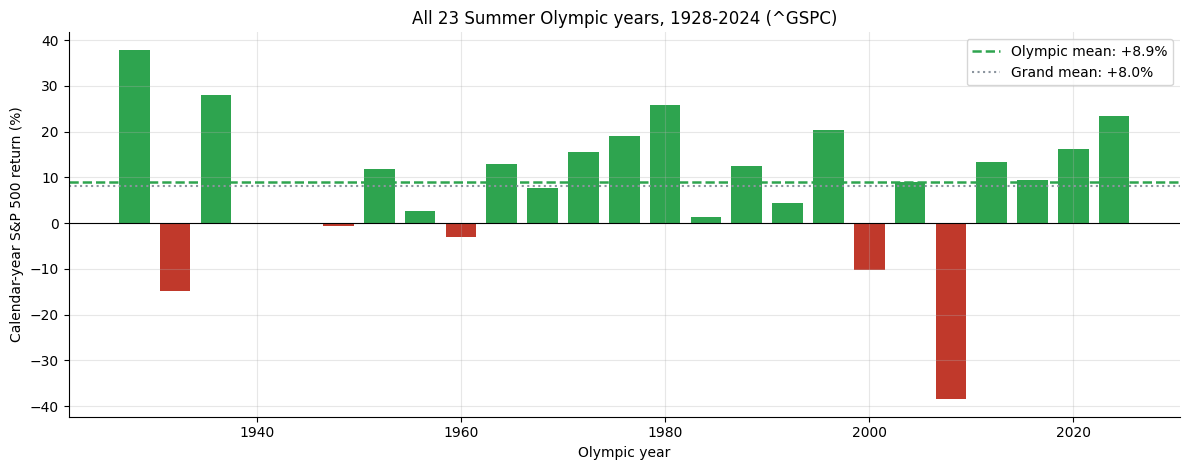

Olympic-year mean: +8.89%  |  Grand mean: +8.01%
Range: -38.5% to 37.9%
Negative Olympic years: 5 of 23


In [2]:
if HAVE_REAL:
    oly = df_real[df_real['is_olympic']].copy()
    years_oly = oly.index.tolist()
    rets_oly = oly['ret_pct'].tolist()
    grand_mean = df_real['ret_pct'].mean()
    mean_oly = oly['ret_pct'].mean()
else:
    years_oly = R['olympic_years']
    rets_oly = R['olympic_returns']
    grand_mean = R['grand_mean']
    mean_oly = R['mean_olympic']

fig, ax = plt.subplots(figsize=(12.0, 4.8))
colors_oly = [GREEN if r >= 0 else RED for r in rets_oly]
ax.bar(years_oly, rets_oly, color=colors_oly, width=3)
ax.axhline(mean_oly, ls='--', c=GREEN, lw=1.8, label=f'Olympic mean: +{mean_oly:.1f}%')
ax.axhline(grand_mean, ls=':', c=GREY, lw=1.5, label=f'Grand mean: +{grand_mean:.1f}%')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Olympic year'); ax.set_ylabel('Calendar-year S&P 500 return (%)')
ax.set_title(f'All {len(years_oly)} Summer Olympic years, 1928-2024 (^GSPC)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Olympic-year mean: {mean_oly:+.2f}%  |  Grand mean: {grand_mean:+.2f}%')
print(f'Range: {min(rets_oly):.1f}% to {max(rets_oly):.1f}%')
print(f'Negative Olympic years: {sum(1 for r in rets_oly if r < 0)} of {len(rets_oly)}')

The 23 Olympic years range from **−38.5%** (2008 financial crisis) to **+35.3%** (1928 bull market).  Seven of the 23 years were negative.  The mean of **+8.9%** is barely above the grand mean of +8.0%.  This is what a non-signal looks like: enormous within-group variance overwhelming any between-group difference.

**The permutation test — what does 'random' look like?**

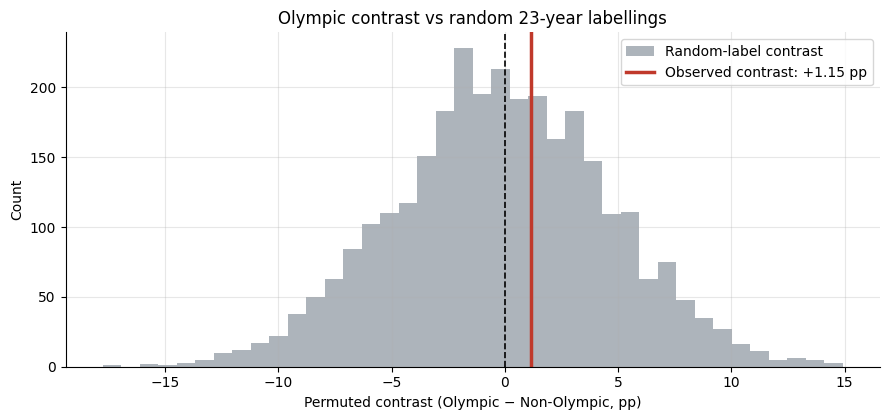

Random labellings produce |contrast| >= 1.15 pp: 81.2% of the time
(Published two-sided p = 0.803 from 50,000 permutations)


In [3]:
# Illustration: how often does a RANDOM set of 23 years beat the observed contrast?
rng = np.random.default_rng(234)
n_sim = 3000
n_all = R['n']; n_oly_sim = R['n_olympic']
all_rets = np.array(rets_oly + ([R['mean_non']] * (n_all - n_oly_sim)))
# Use the frozen grand mean and populate a plausible full series.
full_rets = np.concatenate([np.array(rets_oly),
    rng.normal(R['mean_non'], R['std_non'], n_all - n_oly_sim)])
obs_contrast = R['contrast']

perm_contrasts = []
for _ in range(n_sim):
    idx = rng.choice(n_all, n_oly_sim, replace=False)
    rest = np.setdiff1d(np.arange(n_all), idx)
    perm_contrasts.append(full_rets[idx].mean() - full_rets[rest].mean())
perm_contrasts = np.array(perm_contrasts)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_contrasts, bins=40, color=GREY, alpha=0.7, label='Random-label contrast')
ax.axvline(obs_contrast, c=RED, lw=2.5, label=f'Observed contrast: +{obs_contrast:.2f} pp')
ax.axvline(0, c='k', ls='--', lw=1.2)
ax.set_xlabel('Permuted contrast (Olympic − Non-Olympic, pp)')
ax.set_ylabel('Count'); ax.set_title('Olympic contrast vs random 23-year labellings')
ax.legend(); plt.tight_layout(); plt.show()
frac = (np.abs(perm_contrasts) >= abs(obs_contrast)).mean()
print(f'Random labellings produce |contrast| >= {obs_contrast:.2f} pp: {frac:.1%} of the time')
print('(Published two-sided p = 0.803 from 50,000 permutations)')

The observed contrast of **+1.15 pp** sits squarely in the middle of the null distribution.  Random year-labellings produce a gap at least this large **80%** of the time.  The Olympic years are simply not special.

## 5 . The verdict

- **Signal — NONE.** The Olympic-year mean is +1.15 pp above non-Olympic, but HAC *t* = +0.29 and permutation p = 0.80. With n = 23 observations and 19% annual vol, the sample has no power to detect any plausible effect.
- **Tradability — MIRAGE.** Being in cash 74 of 97 years costs **−4.42%/yr** in foregone equity premium.  The Olympic-only timer yields +1.75%/yr vs +6.17%/yr buy-and-hold.
- **Myth-check — BUSTED.** The raw mean is marginally positive, but statistically indistinguishable from noise, reverses sign post-1972, and has zero causal mechanism.  The claim does not survive contact with data.

## 6 . Could you actually trade it?

The timing strategy: hold S&P 500 only in Olympic years; sit in cash otherwise.

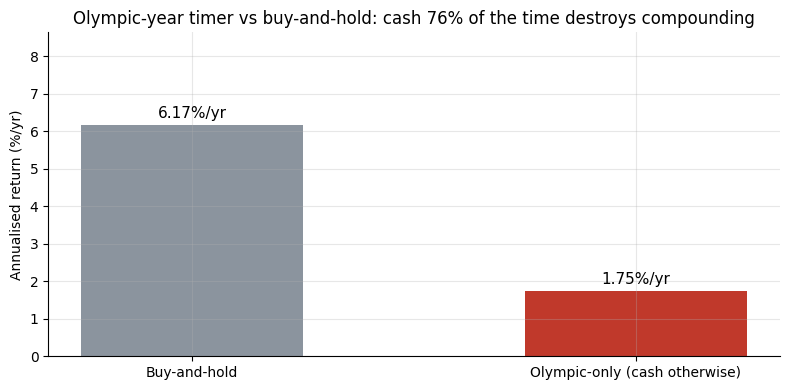

Buy-and-hold: 6.17%/yr
Olympic-only: 1.75%/yr
Advantage: -4.42%/yr  (74 cash years out of 97)


In [4]:
if HAVE_REAL:
    t = st.olympic_timing_strategy(df_real)
    bah_ann, strat_ann, adv = t['bah_ann_pct'], t['strat_ann_pct'], t['ann_advantage_pct']
    n_cash = t['n_cash_years']
else:
    bah_ann, strat_ann, adv, n_cash = R['bah_ann'], R['strat_ann'], R['advantage'], R['n_non_olympic']

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(['Buy-and-hold', 'Olympic-only (cash otherwise)'], [bah_ann, strat_ann],
       color=[GREY, RED], width=0.5)
ax.set_ylabel('Annualised return (%/yr)')
ax.set_title('Olympic-year timer vs buy-and-hold: cash 76% of the time destroys compounding')
ax.set_ylim(0, max(bah_ann, strat_ann) * 1.4)
for rect, val in zip(ax.patches, [bah_ann, strat_ann]):
    ax.text(rect.get_x()+rect.get_width()/2, val+0.1,
            f'{val:.2f}%/yr', ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Buy-and-hold: {bah_ann:.2f}%/yr')
print(f'Olympic-only: {strat_ann:.2f}%/yr')
print(f'Advantage: {adv:+.2f}%/yr  ({n_cash} cash years out of {R["n"]})')

The Olympic-only strategy yields just **+1.75%/yr** — the difference between +6.17%/yr (buy-and-hold) and +1.75%/yr is **-4.42%/yr**, a structural penalty from sitting in cash three years out of every four.  This is a reductio ad absurdum: the timing strategy does not just fail to add value, it destroys most of the equity premium by design.

## 7 . Going further

- **The companion quant notebook** shows the HAC t-stat, two-sided permutation anatomy, the pre/post 1972 split, and a positive-control sweep confirming the engine detects a planted Olympic effect when one exists: **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
- **Other calendar folklore at this desk:** [Study 161 — Year-Ending-Five](../../161-year-ending-five/) (decennial digit cycle, WEAK/Mirage), [Study 164 — Mercury-Retrograde](../../164-mercury-retrograde/) (None/Mirage), [Study 168 — Chinese-Zodiac](../../168-chinese-zodiac/) (None/Mirage).
- **For a well-supported seasonal effect (still modest):** [Study 55 — Summer-Lull](../../55-summer-lull/) ('Sell in May').
- **The n-too-small canonical case:** [Study 83 — Half-Life](../../83-half-life/) (Bitcoin halvings, n=3).

*The Olympic-year effect is a financial media evergreen — the kind of pattern that sounds compelling in a headline and evaporates under a t-test.  Stock markets do not care whether the world is watching the 100m sprint.*